In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
np.random.seed(42)
n = 1000
data = {
    'customer_id': np.arange(1, n+1),
    'age': np.random.randint(18, 70, size=n),
    'tenure': np.random.randint(1, 10, size=n),
    'balance': np.random.randint(0, 2500, size=n),
    'num_products' : np.random.randint(1, 4, size=n),
    'has_credit_card': np.random.choice([0,1], size=n),
    'is_active_member': np.random.choice([0,1], size=n),
    'estimated_salary': np.random.uniform(3e4, 1.5e5, size=n),
    'churn' : np.random.choice([0,1], size=n, p=[0.8, 0.2])
}

In [4]:
df = pd.DataFrame(data)
df.to_csv('customer_churn.csv', index=False)
df.head()

,customer_id,age,tenure,balance,num_products,has_credit_card,is_active_member,estimated_salary,churn
0,1,56,3,1763,1,1,1,30750.896523,0
1,2,69,3,42,3,0,1,37426.284202,1
2,3,46,9,943,3,1,0,94244.152942,0
3,4,32,7,2390,3,1,0,97928.597574,0
4,5,60,5,1349,3,1,0,120174.353335,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1000 non-null   int64  
 1   age               1000 non-null   int32  
 2   tenure            1000 non-null   int32  
 3   balance           1000 non-null   int32  
 4   num_products      1000 non-null   int32  
 5   has_credit_card   1000 non-null   int64  
 6   is_active_member  1000 non-null   int64  
 7   estimated_salary  1000 non-null   float64
 8   churn             1000 non-null   int64  
dtypes: float64(1), int32(4), int64(4)
memory usage: 54.8 KB


In [5]:
print(df.isnull().sum())

customer_id         0
age                 0
tenure              0
balance             0
num_products        0
has_credit_card     0
is_active_member    0
estimated_salary    0
churn               0
dtype: int64


In [7]:
df.describe()

,customer_id,age,tenure,balance,num_products,has_credit_card,is_active_member,estimated_salary,churn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,4.975000,1279.070000,1.982000,0.487000,0.515000,88530.818302,0.198000
std,288.819436,14.99103,2.622452,720.079796,0.834489,0.500081,0.500025,34619.633588,0.398692
min,1.000000,18.00000,1.000000,1.000000,1.000000,0.000000,0.000000,30022.383380,0.000000
25%,250.750000,31.00000,3.000000,650.500000,1.000000,0.000000,0.000000,58097.137347,0.000000
50%,500.500000,44.00000,5.000000,1285.000000,2.000000,0.000000,1.000000,88381.878420,0.000000
75%,750.250000,56.00000,7.000000,1899.250000,3.000000,1.000000,1.000000,118201.309930,0.000000
max,1000.000000,69.00000,9.000000,2496.000000,3.000000,1.000000,1.000000,149629.106231,1.000000


In [9]:
# 특징 및 라벨 분리
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

# 범주형 변수 처리
X = pd.get_dummies(X, drop_first=True)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train

array([[-0.12149869, -1.16352024,  0.57587455, ..., -0.99750312,
         0.99252792, -0.93929836],
       [-1.4818759 ,  1.5090447 , -0.6250759 , ...,  1.00250313,
         0.99252792, -0.84811503],
       [ 1.4429351 , -1.54531523, -0.55123556, ...,  1.00250313,
        -1.00752834,  1.54608644],
       ...,
       [ 0.49067105, -0.01813526, -1.192114  , ...,  1.00250313,
         0.99252792,  0.57931263],
       [ 1.30689738,  0.36365973,  1.67790682, ...,  1.00250313,
         0.99252792,  0.8358146 ],
       [-0.12149869, -0.01813526, -0.21407778, ..., -0.99750312,
         0.99252792,  1.58093629]], shape=(800, 7))

In [12]:
# 변수가 잘 나누어졌는지 확인인
y_test.sum() / len(y_test), y_train.sum() / len(y_train)

(np.float64(0.19), np.float64(0.2))

In [10]:
from sklearn.linear_model import LogisticRegression

# 모델 훈련
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[162   0]
 [ 38   0]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



C:\Users\Yr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Yr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Yr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:156

In [21]:
from sklearn.ensemble import RandomForestClassifier

# 모델 훈련
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[159   3]
 [ 36   2]]
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       162
           1       0.40      0.05      0.09        38

    accuracy                           0.81       200
   macro avg       0.61      0.52      0.49       200
weighted avg       0.74      0.81      0.74       200



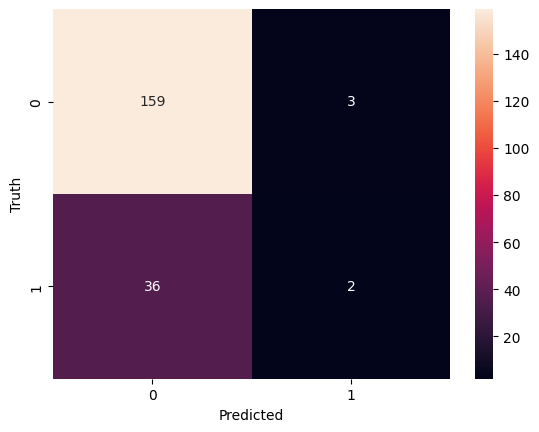

In [22]:
# 시각화
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [23]:
import xgboost as xgb

# 모델 훈련
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[144  18]
 [ 36   2]]
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       162
           1       0.10      0.05      0.07        38

    accuracy                           0.73       200
   macro avg       0.45      0.47      0.46       200
weighted avg       0.67      0.73      0.70       200



In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
# 랜덤 포레스트 모델 튜닝
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
# 최적 하이퍼파라미터
print(f'Best Parameters: {grid_search.best_params_}')
# 최적 모델 예측
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)
# 성능 평가
print(f'Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')

Best Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy: 0.8100


In [28]:
X_train.shape

(800, 7)

In [29]:
import joblib

# 모델 저장
joblib.dump(best_rf_model, 'best_rf_model.pkl')

# 모델 로드 후 예측
model = joblib.load('best_rf_model.pkl')
new_data = np.array([0.3,0.5,0.8, .4,.5,.9,.2])
new_prediction = model.predict(new_data.reshape(1, -1))
print(f'Predicted Churn: {new_prediction[0]}')

Predicted Churn: 0
